#EDA


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importing the modules

In [57]:
df=pd.read_csv("bodyweight.csv")

Reading the file


In [36]:
df_copy=df.copy()

Making the copy of a file

##Data Profiling

In [37]:
print("Basic Info:\n\n")
print(df_copy.info())

Basic Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Density   252 non-null    float64
 1   Age       252 non-null    int64  
 2   Weight    252 non-null    float64
 3   Height    252 non-null    float64
 4   Neck      252 non-null    float64
 5   Chest     252 non-null    float64
 6   Abdomen   252 non-null    float64
 7   Hip       252 non-null    float64
 8   Thigh     252 non-null    float64
 9   Knee      252 non-null    float64
 10  Ankle     252 non-null    float64
 11  Biceps    252 non-null    float64
 12  Forearm   252 non-null    float64
 13  Wrist     252 non-null    float64
 14  Category  252 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 29.7+ KB
None


Basic information of the columns of file

In [38]:
df_copy.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


Stats of the features

In [39]:
df_copy['Category'].value_counts()

,count
Category,
Lean,63
Average,56
Slightly Fat,54
Fat,41
Obese,25
Muscular,13


all the values of category feature

##Data Quality check

In [40]:
print("Null Values:\n",df_copy.isnull().sum())
print("\n\nDuplicated Values",df_copy.duplicated().sum())

Null Values:
 Density     0
Age         0
Weight      0
Height      0
Neck        0
Chest       0
Abdomen     0
Hip         0
Thigh       0
Knee        0
Ankle       0
Biceps      0
Forearm     0
Wrist       0
Category    0
dtype: int64


Duplicated Values 0


Checking null and duplicated values

##Data visualization


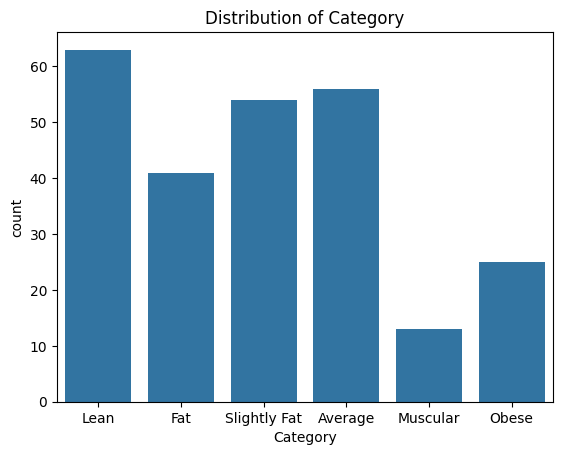

In [41]:
# Category distribution
sns.countplot(x='Category', data=df)
plt.title("Distribution of Category")
plt.show()


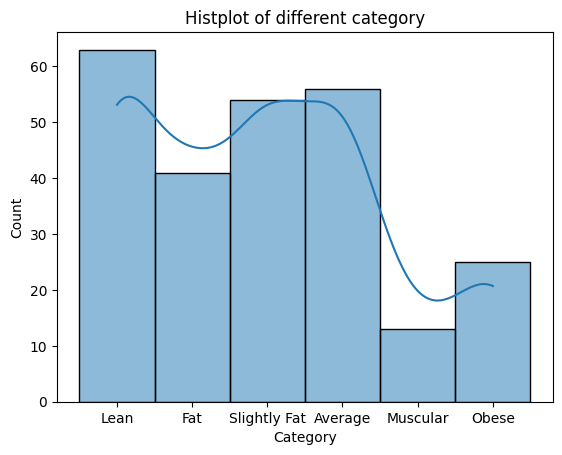

In [42]:
sns.histplot(x='Category', data=df,kde=True)
plt.title("Histplot of different category")
plt.show()

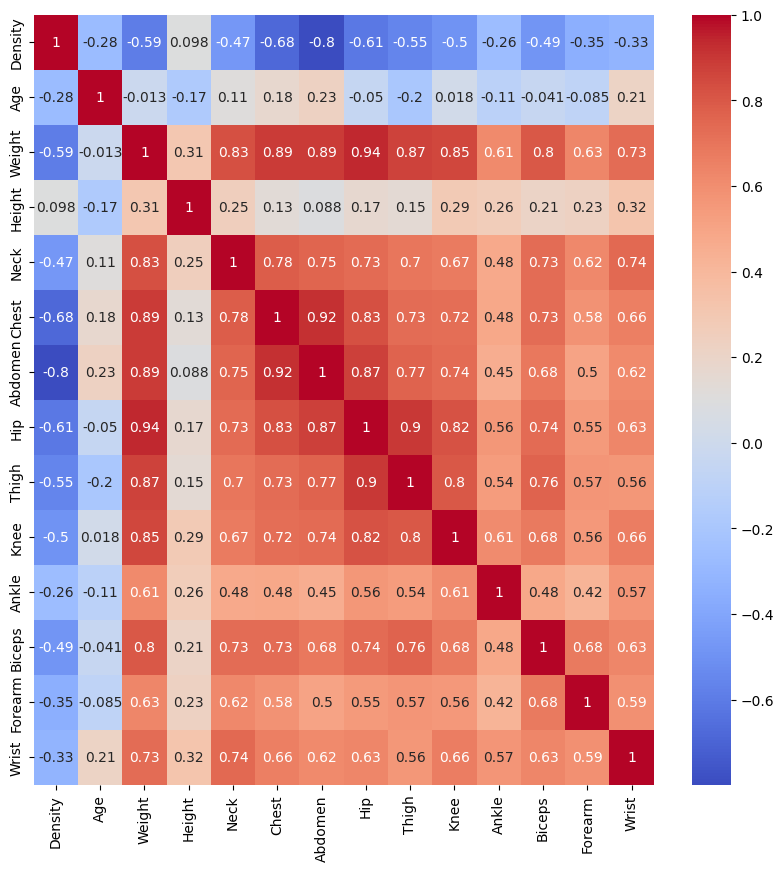

In [43]:
plt.figure(figsize=(10,10))
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


Text(0.5, 1.0, 'Boxplot')

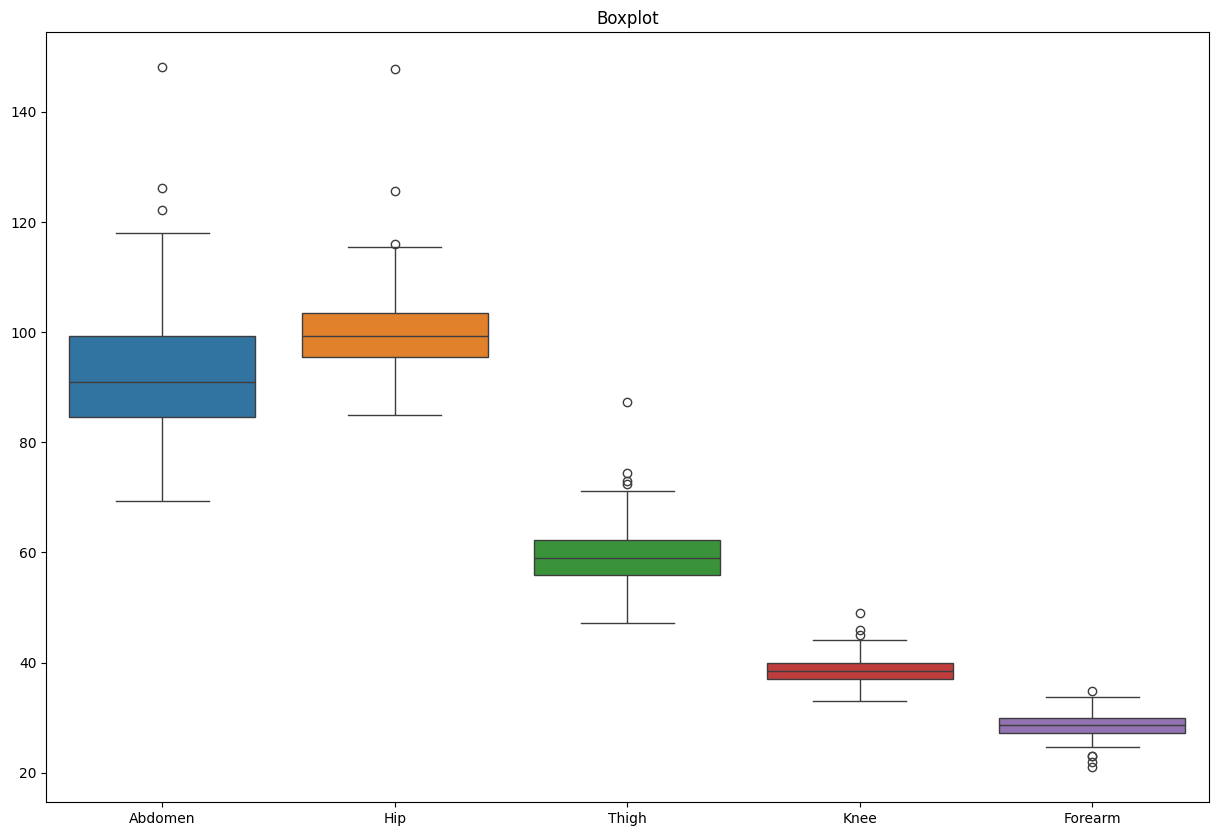

In [44]:
plt.figure(figsize=(15,10))
sns.boxplot(df_copy[[
    'Abdomen','Hip','Thigh','Knee','Forearm'
    ]])
# Add labels and title
plt.title("Boxplot")


In [45]:
# List of columns to remove outliers from
columns = ['Abdomen', 'Hip','Thigh','Knee','Forearm']
df_no_outliers = df_copy.copy()
for column in columns:
    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_limit) & (df_no_outliers[column] <= upper_limit)
    ]


Text(0.5, 1.0, 'Boxplot')

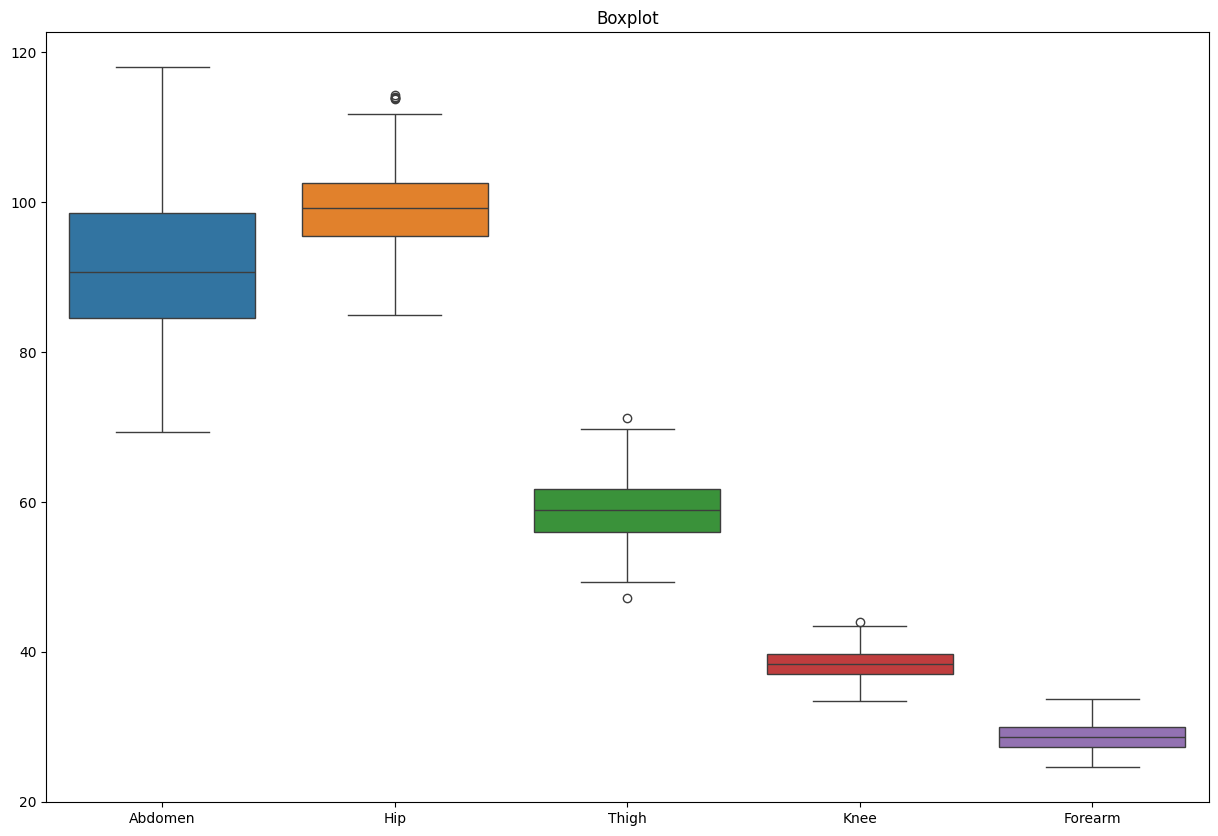

In [46]:
plt.figure(figsize=(15,10))
sns.boxplot(df_no_outliers[[
    'Abdomen','Hip','Thigh','Knee','Forearm'
    ]])
# Add labels and title
plt.title("Boxplot")


# Logistic Regression

##Baseline Model

In [58]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode target if it's categorical
if df['Category'].dtype == 'object':
    le = LabelEncoder()
    df['Category'] = le.fit_transform(df['Category'])  # e.g., Lean=0, Fat=1

print(dict(zip(le.classes_, le.transform(le.classes_))))

# Split features and target
X = df.drop(columns=['Category'])
y = df['Category']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
# New data (same number of features as training)
new_data = [[5.1, 3.5, 1.4, 0.2,23,0.5,8,2,4,1,3,5,5,12]]  # replace with your values
# Scale new data just like training data
new_data_scaled = scaler.transform(new_data)

# Predict on scaled data
pred = model.predict(new_data_scaled)

# Get original label from encoded prediction
print("Predicted:", pred,le.inverse_transform(pred)[0])


{'Average': np.int64(0), 'Fat': np.int64(1), 'Lean': np.int64(2), 'Muscular': np.int64(3), 'Obese': np.int64(4), 'Slightly Fat': np.int64(5)}
Accuracy: 0.6078431372549019
Predicted: [3] Muscular


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


##Fine_tuned Model

In [59]:
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ["l1",'l2']
}

model = LogisticRegression(solver="liblinear")

# Grid Search with cross-validation
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Parameters:", grid.best_params_)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

# Predict on new data
new_data = [[5.1, 3.5, 1.4, 0.2,23,0.5,8,2,4,1,3,5,5,12]]
pred = best_model.predict(new_data)

# Inverse transform to original label
print("Predicted Class:", le.inverse_transform(pred)[0])

Best Parameters: {'C': 1.0, 'penalty': 'l1'}
Tuned Accuracy: 0.5098039215686274
Predicted Class: Muscular


In [60]:
import joblib

joblib.dump((model, scaler, le), "base.pkl")
joblib.dump((best_model, scaler, le), "fine.pkl")


['fine.pkl']

#Findings


1. The model is 60% accurate
2. Lean category has maximum count and muscular has minimum
3. There are no any null and duplicate value
4. Baseline Model gave 60% accuracy whereas Tuned model gave only 50%

In [50]:
import joblib


# Save model to file
joblib.dump(model, "base.pkl")
joblib.dump(best_model,"fine.pkl")

['fine.pkl']